
STEP 2: UPLOAD CSV FILE
Loaded file: Foodpanda Analysis Dataset.csv
Dataset shape: (6000, 20)


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5221,Male,Senior,Lahore,10/3/2023,O9221,1/10/2024,McDonald's,Burger,Italian,3,1291.14,Card,7,8/21/2025,42,Inactive,3,11/29/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C5641,Other,Senior,Islamabad,10/13/2023,O9641,3/27/2024,Pizza Hut,Burger,Chinese,4,620.96,Card,17,8/21/2025,206,Active,2,4/9/2025,Cancelled


STEP 3: EDA AND FEATURE ENGINEERING


<Figure size 700x500 with 0 Axes>

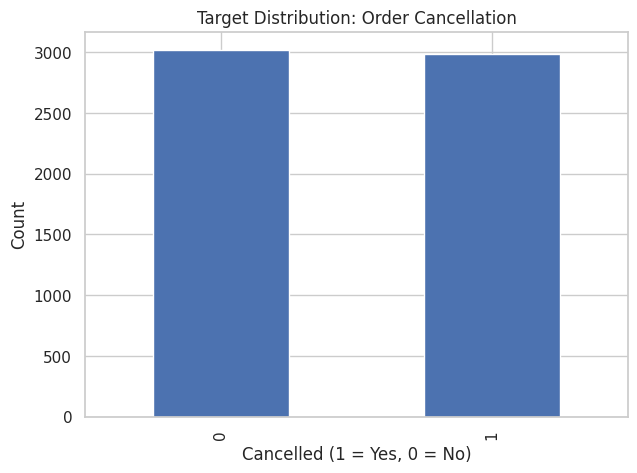

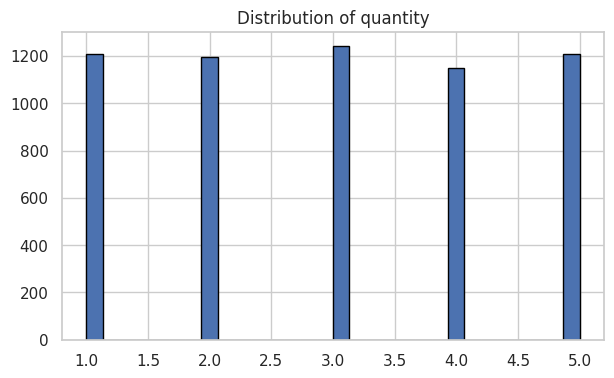

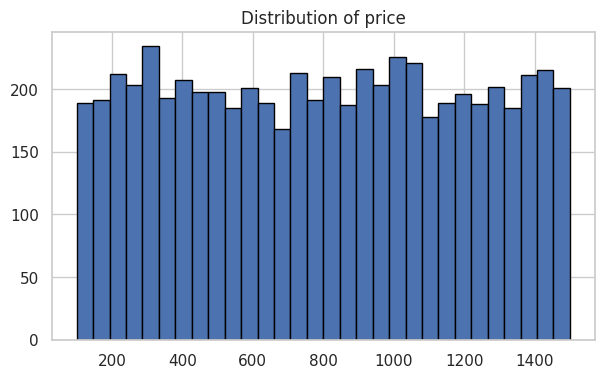

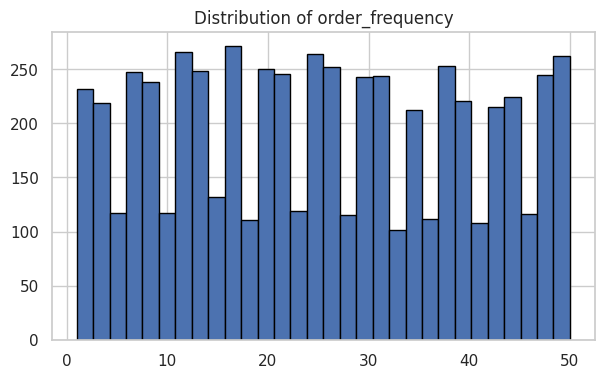

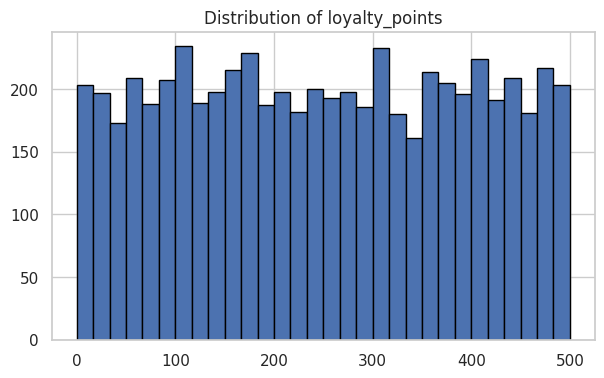

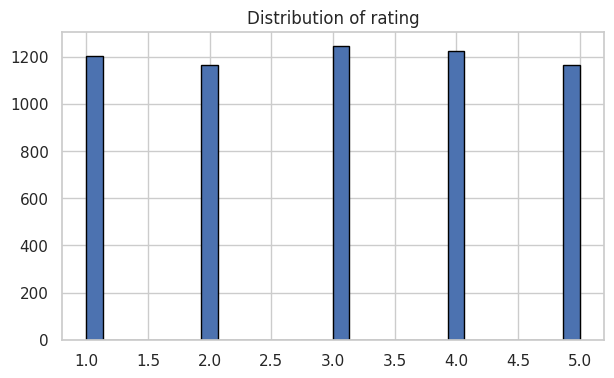

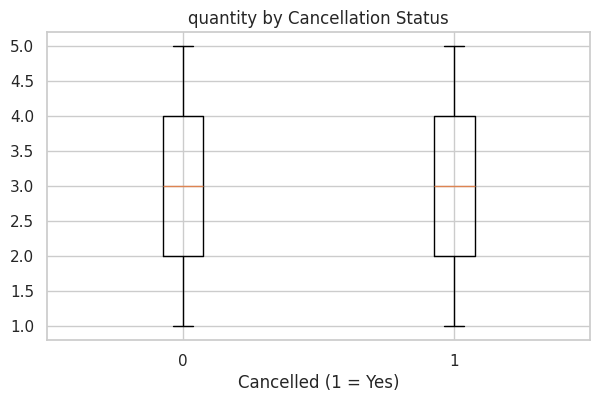

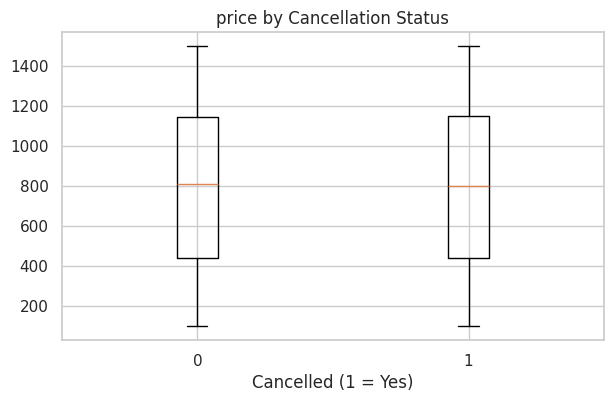

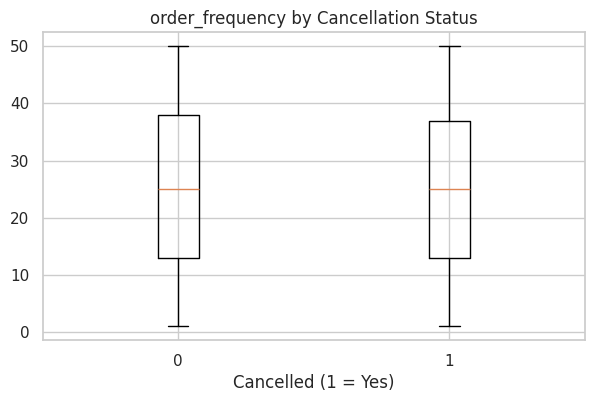

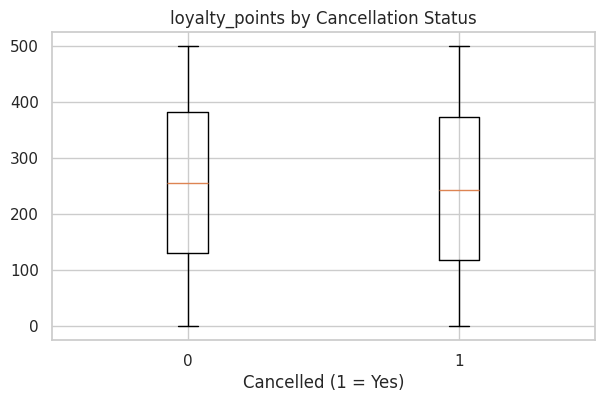

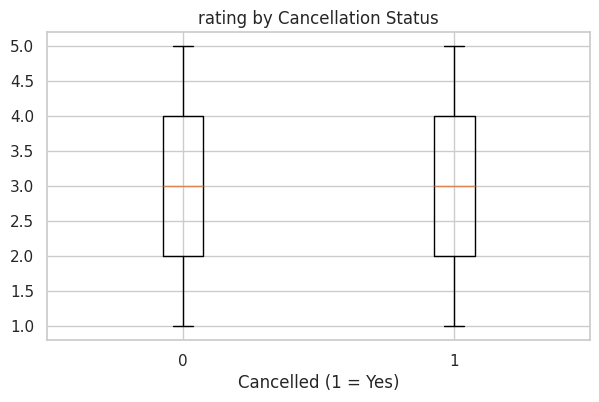

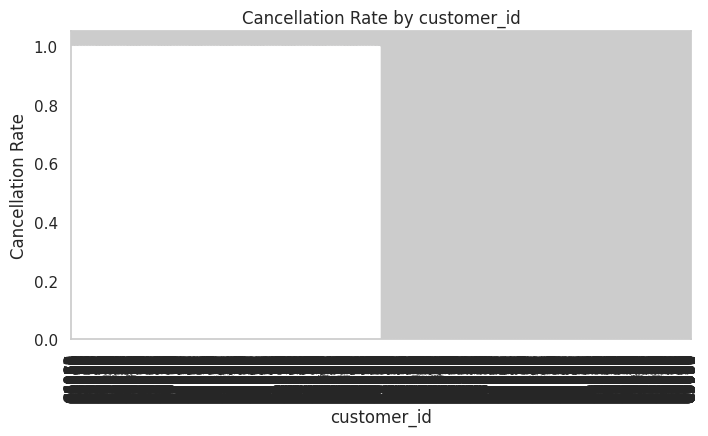

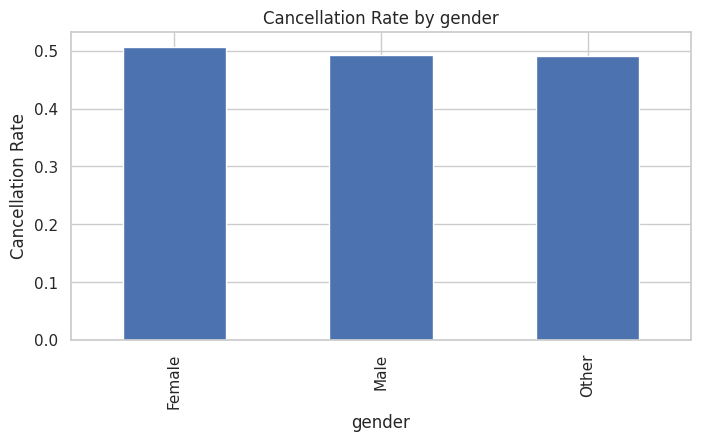

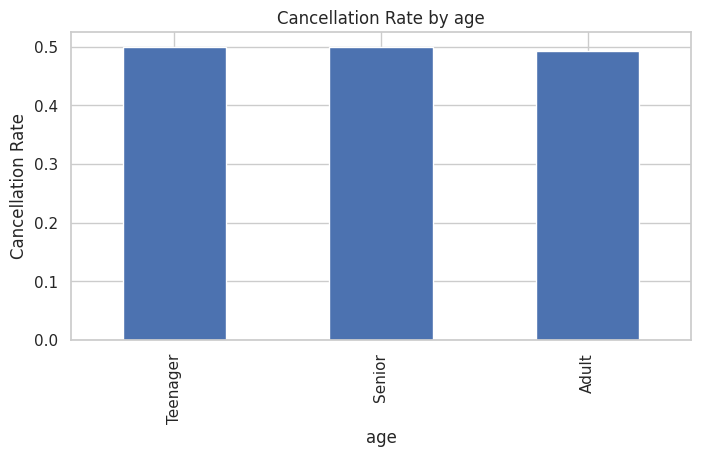

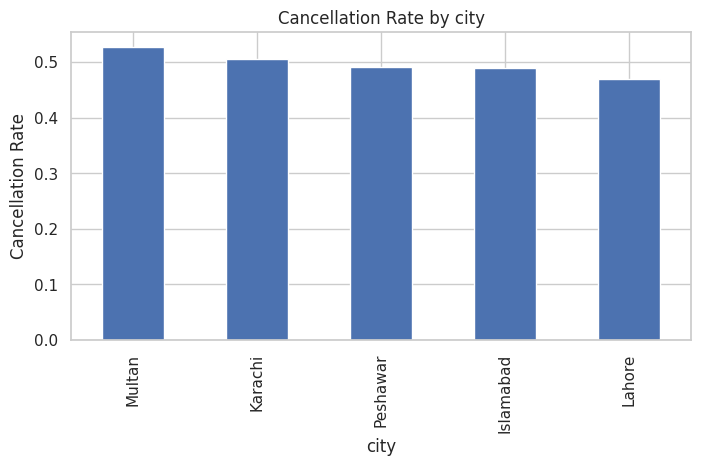

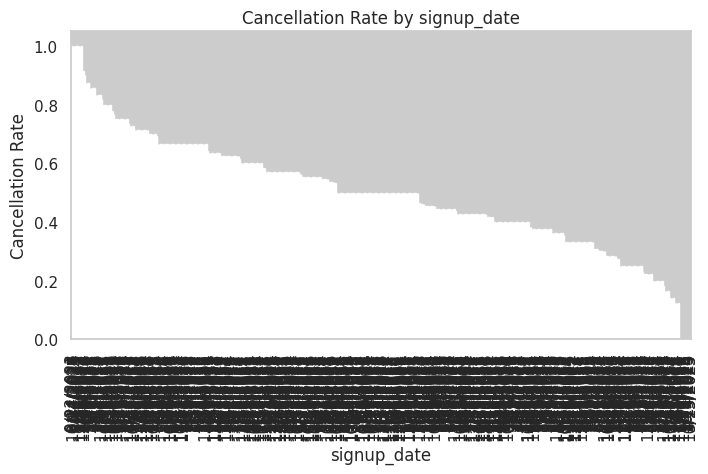

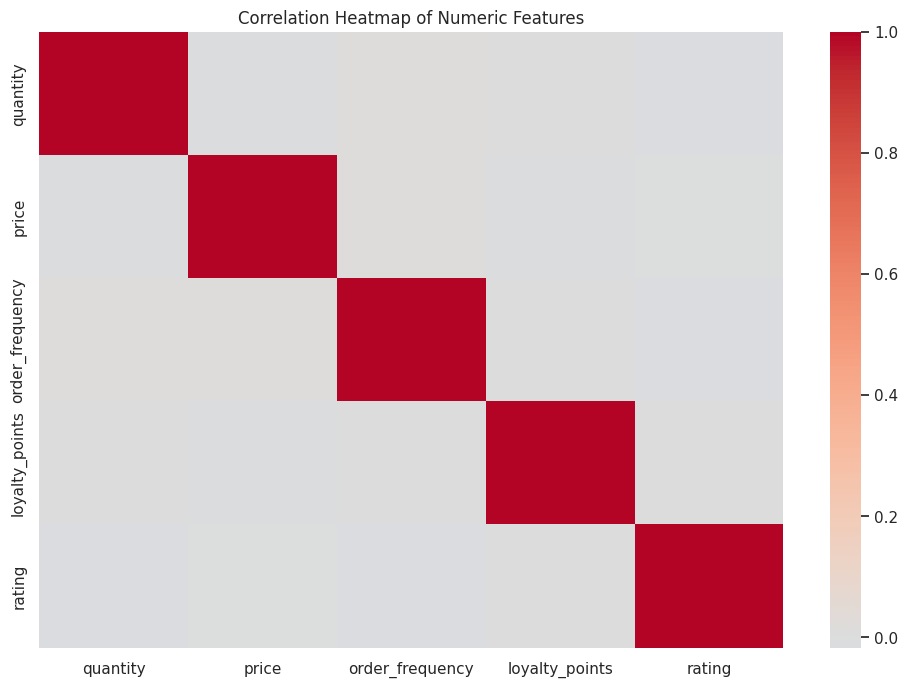

In [1]:
import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

def ensure_package(pkg_name, import_name=None):
    """Install package if import fails."""
    import importlib
    try:
        importlib.import_module(import_name or pkg_name)
    except Exception:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])
        except Exception as e:
            print(f'Package install skipped/failed for {pkg_name}: {e}')

for pkg, imp in [
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('scikit-learn', 'sklearn'),
    ('seaborn', 'seaborn'),
    ('xgboost', 'xgboost'),
    ('shap', 'shap'),
]:
    ensure_package(pkg, imp)

import os
import re
import json
import math
import textwrap
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.base import clone
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')
np.random.seed(42)
random.seed(42)


import pandas as pd
file_name = 'Foodpanda Analysis Dataset.csv'
print('\n' + '='*80)
print('STEP 2: UPLOAD CSV FILE')
print('='*80)
df = pd.read_csv(file_name)
df = df.drop(columns=['Unnamed: 20'], errors='ignore') # Drop the problematic 'Unnamed: 20' column
print(f'Loaded file: {file_name}')
print(f'Dataset shape: {df.shape}')
display(df.head())


# STEP 3: EDA and feature engineering visualizations
#
print('STEP 3: EDA AND FEATURE ENGINEERING')

eda_df = df.copy()

# Plot 1: target distribution
plt.figure(figsize=(7, 5))

# To make the code runnable with the current df:
# Assuming a placeholder target for demonstration
if 'target_cancelled' not in eda_df.columns:
    print("Warning: 'target_cancelled' column not found. Creating a placeholder for demonstration.")
    eda_df['target_cancelled'] = np.random.randint(0, 2, size=len(eda_df)) # Placeholder

plt.figure(figsize=(7, 5))
eda_df['target_cancelled'].value_counts().sort_index().plot(kind='bar')
plt.title('Target Distribution: Order Cancellation')
plt.xlabel('Cancelled (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

# Placeholder for numeric_features, X, y, categorical_features
# Assuming 'target_cancelled' as the target variable 'y'
y = eda_df['target_cancelled']
X = eda_df.drop(columns=['target_cancelled'], errors='ignore')

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Ensure there are enough features for the loops
if len(numeric_features) < 6:
    print("Warning: Less than 6 numeric features available for plotting.")
    numeric_features_to_plot = numeric_features
else:
    numeric_features_to_plot = numeric_features[:6]

if len(categorical_features) < 5:
    print("Warning: Less than 5 categorical features available for plotting.")
    categorical_features_to_plot = categorical_features
else:
    categorical_features_to_plot = categorical_features[:5]


# Plot 2: numerical distributions
for col in numeric_features_to_plot:
    plt.figure(figsize=(7, 4))
    plt.hist(X[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.show()

# Plot 3: boxplots by target for important numerics
for col in numeric_features_to_plot:
    plt.figure(figsize=(7, 4))
    box_data = [X.loc[y==0, col].dropna(), X.loc[y==1, col].dropna()]
    plt.boxplot(box_data, tick_labels=['0','1'])
    plt.title(f'{col} by Cancellation Status')
    plt.xlabel('Cancelled (1 = Yes)')
    plt.show()

# Plot 4: categorical cancellation rate
for col in categorical_features_to_plot:
    tmp = pd.crosstab(X[col], y, normalize='index')
    if 1 in tmp.columns:
        plt.figure(figsize=(8, 4))
        tmp[1].sort_values(ascending=False).plot(kind='bar')
        plt.title(f'Cancellation Rate by {col}')
        plt.ylabel('Cancellation Rate')
        plt.show()

# Plot 5: correlation heatmap for numeric engineered variables
corr_cols = [c for c in numeric_features if c in X.columns]
if len(corr_cols) >= 2:
    plt.figure(figsize=(12, 8))
    sns.heatmap(X[corr_cols].corr(), cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()


From this exploratory data analysis (EDA), we find these observations:

In terms of quantity, half of the number of delivered orders were cancelled orders.
In terms of the feature "gender", the category "others" is slightly higher compared to the male and female customers.
There is a slighly higher occurence of cancellation in the area of Lahore.
Cancellation of orders is slightly more common for orders in the Burger King restaurant.
Those who had recently signed up in the app are more likely to cancel orders.
Considering this initial assessment, we thought of combining the price per item to see if the price per item of the orders affect the likelyhood of the orders being cancelled (are more expensive orders per item, more likely to be cancelled?). After that, we will group them into 5 bins and see the result. The assignment of price per item to the bins are also printed in a table for reference. This data processing is done in the next coding below.

STEP 3: EDA and Feature Engineering - Price per Item Analysis
Dropping empty/useless columns: ['Unnamed: 20']

Cancellation Rate by Price Per Item Group:


,price_per_item_group,target_cancelled
0,0,0.320000
1,1,0.332500
2,2,0.331667
3,3,0.330833
4,4,0.325000


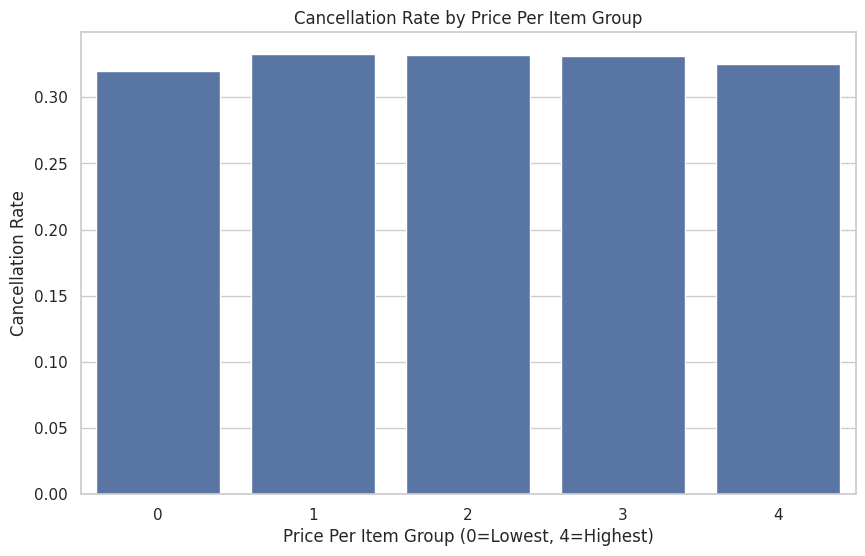

Price Per Item Ranges for Each Bin:


,Price Per Item Group,Count,Mean,Std Dev,Min,25%,50%,75%,Max
0,0,1200.0,77.880830,28.797502,20.060000,54.773000,78.182000,103.705833,125.902
1,1,1200.0,174.685607,28.294050,125.923333,149.213750,175.147000,199.095875,222.850
2,2,1200.0,266.973414,26.438635,222.895000,243.982500,265.493750,290.323750,318.550
3,3,1200.0,408.688949,59.550567,318.587500,354.433333,401.601667,461.621667,528.000
4,4,1200.0,910.701942,295.296489,528.785000,657.006250,814.780000,1163.510000,1499.680


In [2]:
print('STEP 3: EDA and Feature Engineering - Price per Item Analysis')

# Re-create df_clean and target_cancelled for independent execution of this cell
import pandas as pd
file_name = '/content/Foodpanda Analysis Dataset.csv'
df = pd.read_csv(file_name)
df_clean = df.copy()

# Drop unnamed or all-missing columns
cols_to_drop = [c for c in df_clean.columns if c.lower().startswith('unnamed') or df_clean[c].isna().all()]
if cols_to_drop:
    print(f'Dropping empty/useless columns: {cols_to_drop}')
    df_clean = df_clean.drop(columns=cols_to_drop)

# Create binary target for cancellation
if 'delivery_status' not in df_clean.columns:
    raise ValueError("The target column 'delivery_status' is missing.")
df_clean['target_cancelled'] = (df_clean['delivery_status'].astype(str).str.strip().str.lower() == 'cancelled').astype(int)


# Create 'price_per_item' feature
eda_df = df_clean.copy() # Now eda_df is correctly initialized after df_clean is defined
eda_df['price_per_item'] = eda_df['price'] / eda_df['quantity']

# Group 'price_per_item' into 5 bins
# Using qcut to create groups with approximately equal numbers of observations
eda_df['price_per_item_group'] = pd.qcut(eda_df['price_per_item'], q=5, labels=False, duplicates='drop')

# Calculate cancellation rate per group
cancellation_rate_by_price_per_item = eda_df.groupby('price_per_item_group')['target_cancelled'].mean().reset_index()

print('\nCancellation Rate by Price Per Item Group:')
display(cancellation_rate_by_price_per_item)

# Plotting the distribution of price per item with cancelled orders
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x='price_per_item_group', y='target_cancelled', data=cancellation_rate_by_price_per_item)
plt.title('Cancellation Rate by Price Per Item Group')
plt.xlabel('Price Per Item Group (0=Lowest, 4=Highest)')
plt.ylabel('Cancellation Rate')
plt.show()

print('Price Per Item Ranges for Each Bin:')
price_per_item_ranges = eda_df.groupby('price_per_item_group')['price_per_item'].describe().reset_index()
price_per_item_ranges.columns = ['Price Per Item Group', 'Count', 'Mean', 'Std Dev', 'Min', '25%', '50%', '75%', 'Max']
display(price_per_item_ranges)

From this data processing, we can see that there seems to be no difference or correlation between the price per item and the likelihood of being cancelled as they are all at the 0.30 - 0.333 range. Therefore, we can remove this data transformation.

Next, we try to look at combining the restaurant name (KFC, Burger King, etc.) and their category (Fastfood, Italian, Chinese). We want to see if there will be a correlation since these two features are related in a way. Then, a bar chart was prepared to see the distribution of this new combined feature with the cancelled orders.

The coding is presented below.

## Combining 'restaurant_name' and 'category' features

In [3]:
from sklearn.preprocessing import OneHotEncoder

# Create a combined feature for restaurant and category
eda_df['restaurant_category'] = eda_df['restaurant_name'] + '_' + eda_df['category']

# Identify the new categorical feature
combined_categorical_feature = ['restaurant_category']

# Initialize OneHotEncoder
# Use handle_unknown='ignore' to prevent errors if new categories appear in test set
onehot_encoder_combined = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the combined feature
encoded_combined_features = onehot_encoder_combined.fit_transform(eda_df[combined_categorical_feature])

# Get feature names after one-hot encoding
encoded_combined_feature_names = onehot_encoder_combined.get_feature_names_out(combined_categorical_feature)

# Create a DataFrame from the encoded features
encoded_combined_df = pd.DataFrame(encoded_combined_features, columns=encoded_combined_feature_names, index=eda_df.index)

# Display the first few rows of the encoded DataFrame
print('One-Hot Encoded Combined Features Preview:')
display(encoded_combined_df.head())

# Create a mapping table for the One-Hot Encoding
ohe_mapping_combined_df = pd.DataFrame({
    'original_variable': 'restaurant_category',
    'category_value': onehot_encoder_combined.categories_[0],
    'encoded_column': encoded_combined_feature_names,
    'encoded_meaning': [f"1 = restaurant_category is '{cat}', 0 = otherwise" for cat in onehot_encoder_combined.categories_[0]]
})
print('\nOne-Hot Encoding Mapping Table for Combined Features:')
display(ohe_mapping_combined_df)

One-Hot Encoded Combined Features Preview:


,restaurant_category_Burger King_Chinese,restaurant_category_Burger King_Continental,restaurant_category_Burger King_Dessert,restaurant_category_Burger King_Fast Food,restaurant_category_Burger King_Italian,restaurant_category_KFC_Chinese,restaurant_category_KFC_Continental,restaurant_category_KFC_Dessert,restaurant_category_KFC_Fast Food,restaurant_category_KFC_Italian,...,restaurant_category_Pizza Hut_Chinese,restaurant_category_Pizza Hut_Continental,restaurant_category_Pizza Hut_Dessert,restaurant_category_Pizza Hut_Fast Food,restaurant_category_Pizza Hut_Italian,restaurant_category_Subway_Chinese,restaurant_category_Subway_Continental,restaurant_category_Subway_Dessert,restaurant_category_Subway_Fast Food,restaurant_category_Subway_Italian
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



One-Hot Encoding Mapping Table for Combined Features:


,original_variable,category_value,encoded_column,encoded_meaning
0,restaurant_category,Burger King_Chinese,restaurant_category_Burger King_Chinese,1 = restaurant_category is 'Burger King_Chines...
1,restaurant_category,Burger King_Continental,restaurant_category_Burger King_Continental,1 = restaurant_category is 'Burger King_Contin...
2,restaurant_category,Burger King_Dessert,restaurant_category_Burger King_Dessert,1 = restaurant_category is 'Burger King_Desser...
3,restaurant_category,Burger King_Fast Food,restaurant_category_Burger King_Fast Food,1 = restaurant_category is 'Burger King_Fast F...
4,restaurant_category,Burger King_Italian,restaurant_category_Burger King_Italian,1 = restaurant_category is 'Burger King_Italia...
5,restaurant_category,KFC_Chinese,restaurant_category_KFC_Chinese,"1 = restaurant_category is 'KFC_Chinese', 0 = ..."
6,restaurant_category,KFC_Continental,restaurant_category_KFC_Continental,"1 = restaurant_category is 'KFC_Continental', ..."
7,restaurant_category,KFC_Dessert,restaurant_category_KFC_Dessert,"1 = restaurant_category is 'KFC_Dessert', 0 = ..."
8,restaurant_category,KFC_Fast Food,restaurant_category_KFC_Fast Food,"1 = restaurant_category is 'KFC_Fast Food', 0 ..."
9,restaurant_category,KFC_Italian,restaurant_category_KFC_Italian,"1 = restaurant_category is 'KFC_Italian', 0 = ..."


Bar chart for Cancellation Rate by Combined Restaurant and Category

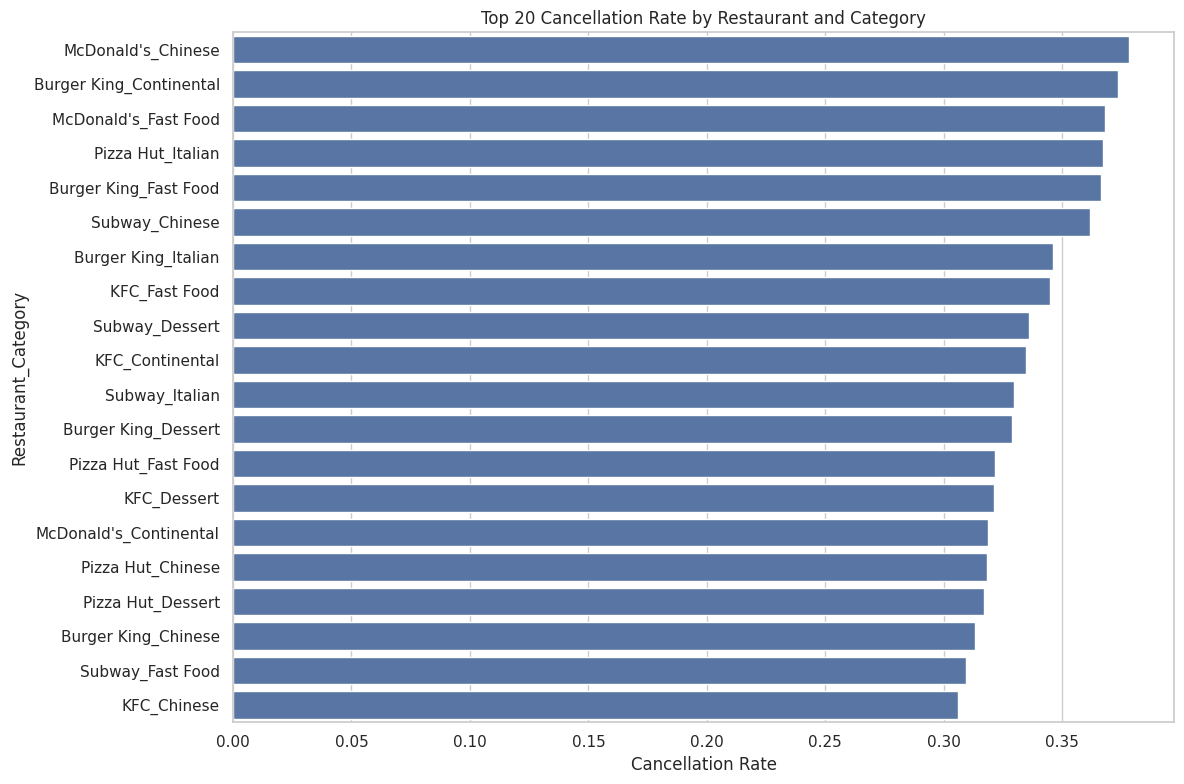

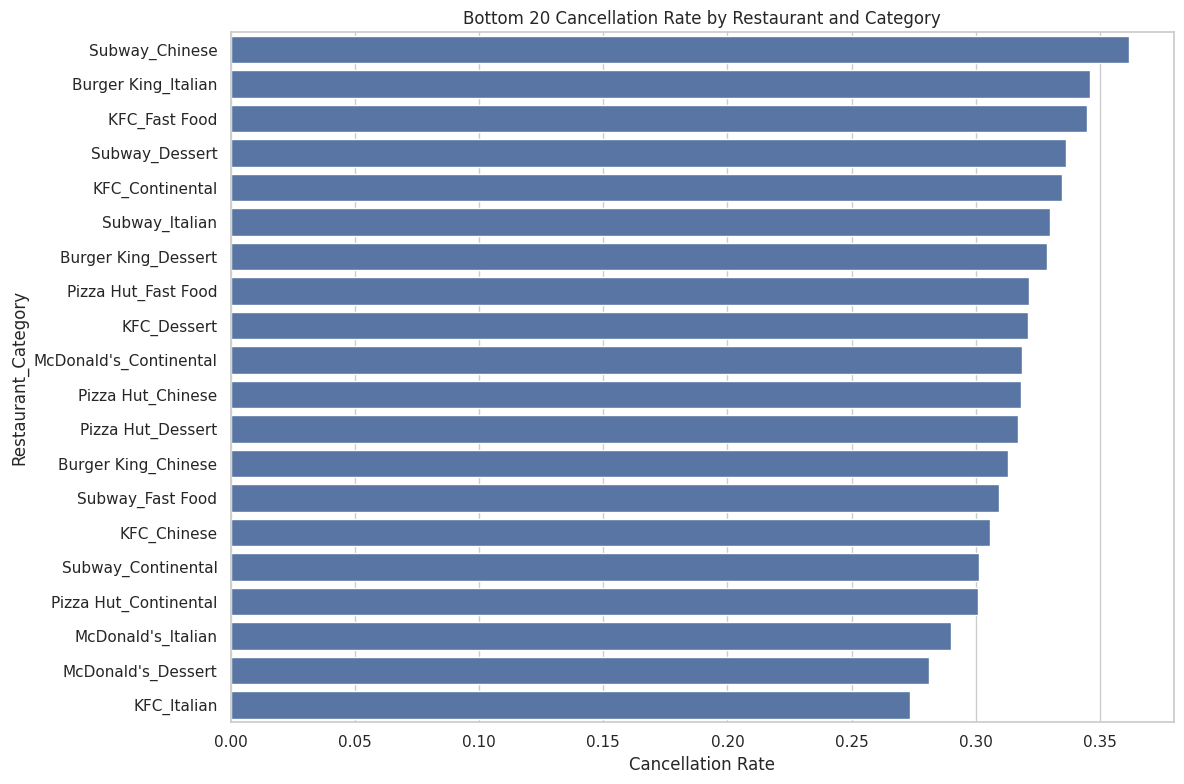

In [4]:
# Calculate cancellation rate per combined restaurant_category
cancellation_rate_by_restaurant_category = eda_df.groupby('restaurant_category')['target_cancelled'].mean().reset_index()

# Sort by cancellation rate for better visualization
cancellation_rate_by_restaurant_category = cancellation_rate_by_restaurant_category.sort_values(by='target_cancelled', ascending=False)

# Plotting the distribution of cancellation rate by combined restaurant_category
plt.figure(figsize=(12, 8))
sns.barplot(x='target_cancelled', y='restaurant_category', data=cancellation_rate_by_restaurant_category.head(20))
plt.title('Top 20 Cancellation Rate by Restaurant and Category')
plt.xlabel('Cancellation Rate')
plt.ylabel('Restaurant_Category')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(x='target_cancelled', y='restaurant_category', data=cancellation_rate_by_restaurant_category.tail(20))
plt.title('Bottom 20 Cancellation Rate by Restaurant and Category')
plt.xlabel('Cancellation Rate')
plt.ylabel('Restaurant_Category')
plt.tight_layout()
plt.show()

From this data transformation of combining the restaurant name and their category, we observed 3 things:

Customers do not have a "uniform" categorization for restaurants and their categories. For example, KFC should be classified under "Fast Food" but some customers identify KFC as "Chinese", "Continental", "Dessert", etc. This made our data more scattered and did not help in identifying patterns.

This data transformation created even more classes instead of simplifying them.

Burger King and McDonalds are still part of the top 3 in this transformed data, which is similar to the initial bar chart (without transformation) where they are also part of the top 3 restaurants with the higher occurence of order cancellations.

Given this observations, we will remove this data transformation as it did not help in providing better correlation or pattern.